In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

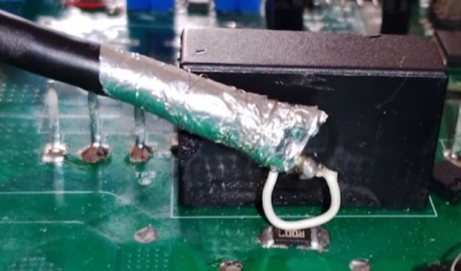

In [39]:
df = pd.read_csv("2026-02-15_14-23-26-419.csv")
vc= df .CH1.values
vb = df.CH3.values
Iin = df.CH2.values
Ts = df.Ts.iloc[0]
time = df.time.values

df.head()

,CH1,CH2,CH3,time,Ts
0,243.992188,0.490000,-0.030000,0.000000e+00,4.000000e-09
1,246.000000,0.479922,-0.010234,4.000000e-09,NaN
2,244.000000,0.470156,-0.020156,8.000000e-09,NaN
3,246.000000,0.459922,-0.049844,1.200000e-08,NaN
4,243.007812,0.450000,-0.010313,1.600000e-08,NaN


<Axes: xlabel='time'>

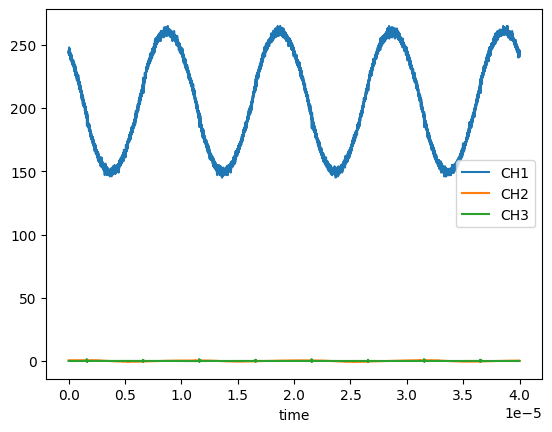

In [4]:
df.plot(x = "time", y= ["CH1", "CH2", "CH3"])

<Axes: xlabel='time'>

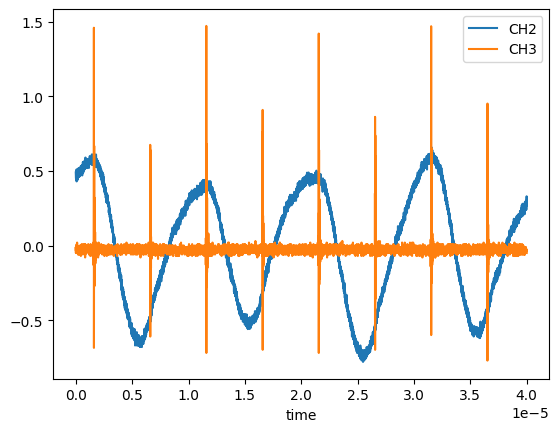

In [12]:
df.plot(x = "time", y= ["CH2", "CH3"])

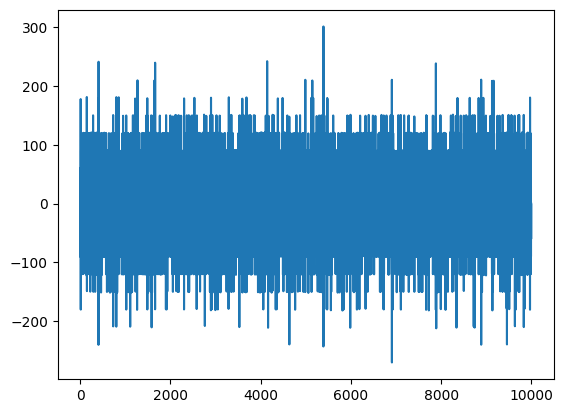

In [22]:
# ic = c dv/dt 
cr= 120e-9
ic = cr*np.diff(vc)/Ts
plt.plot(ic)

In [23]:
from scipy.signal import butter, filtfilt

fs = 1/Ts          # fréquence d'échantillonnage
fc = 5e6            # fréquence de coupure
b, a = butter(4, fc/(fs/2), btype='low')

ic2 = filtfilt(b, a, ic)

(-10.0, 10.0)

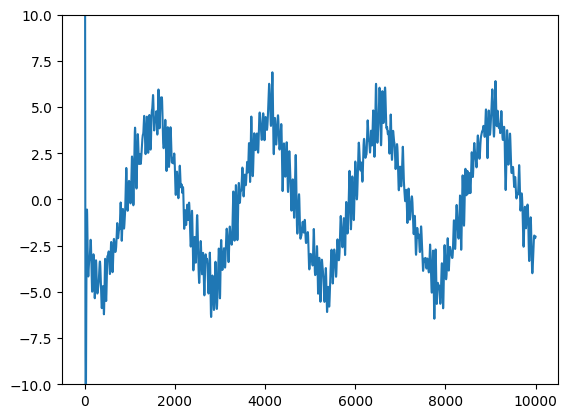

In [28]:
plt.plot(ic2)
plt.ylim([-10,10])

(-10.0, 10.0)

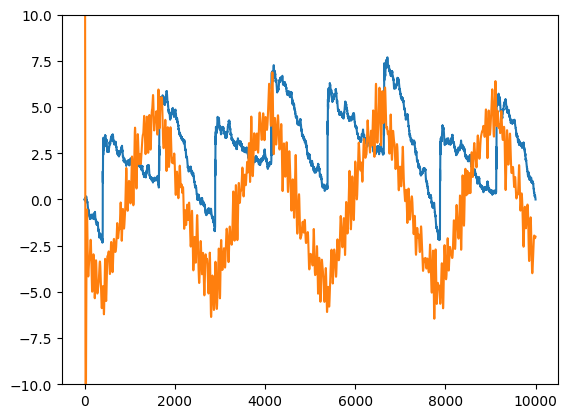

In [55]:
vb2= vb-vb.mean()
k = 5e8
integVb= k*np.cumsum(vb2)*Ts
plt.plot(integVb)

plt.plot(ic2)
plt.ylim([-10,10])

In [40]:
from sklearn.linear_model import LinearRegression

In [ ]:
vb2= vb-vb.mean()
integVb= np.cumsum(vb2)*Ts
plt.plot(integVb)

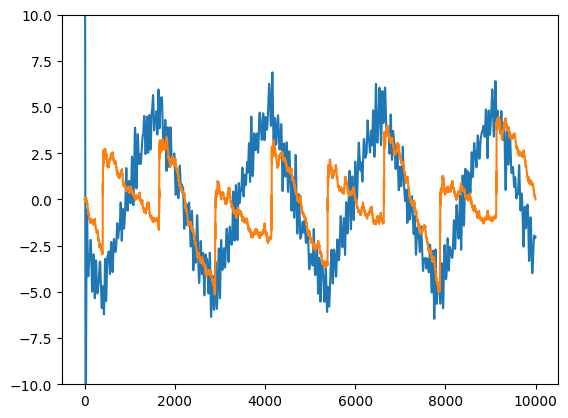

In [57]:
x= time.reshape((-1,1))
vb2 = vb-LinearRegression().fit(x,vb).predict(x)
k = 5e8
integVb= k*np.cumsum(vb2)*Ts


plt.plot(ic2)
plt.ylim([-10,10])
plt.plot(integVb)

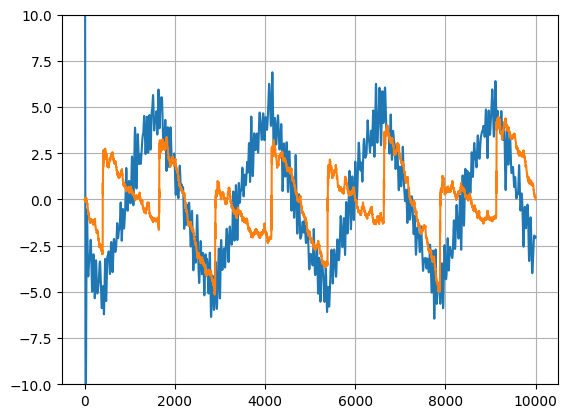

In [59]:

plt.plot(ic2)
plt.ylim([-10,10])
plt.plot(integVb)
plt.grid()

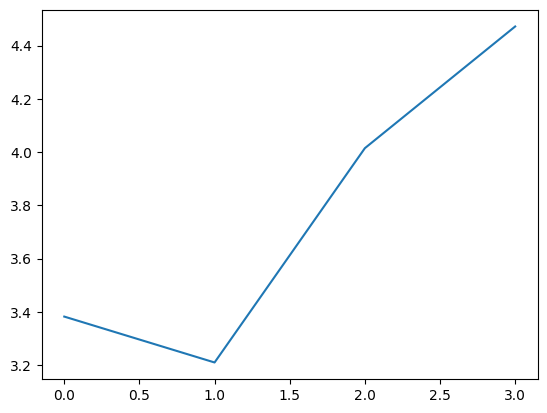

In [69]:
import numpy as np
from scipy.signal import find_peaks

# x = ton signal 1D
peaks, properties = find_peaks(integVb,height=2.5, distance=2000)

#print(peaks)          # indices des pics
plt.plot(integVb[peaks])   # valeur des pics


In [72]:
peaks

array([1819, 4193, 6714, 9179])

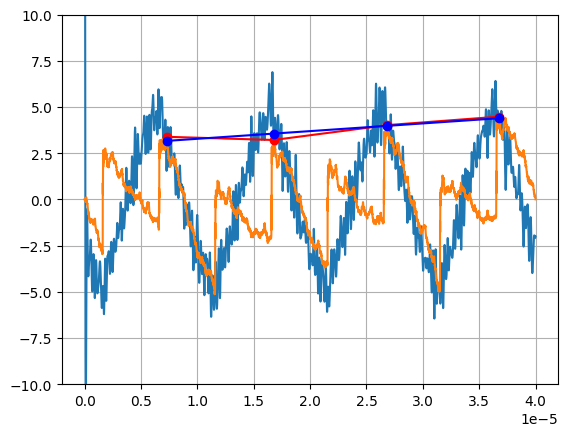

In [80]:
plt.plot(time[1:], ic2)
plt.ylim([-10,10])
plt.plot(time, integVb)

x= time [peaks].reshape((-1,1))
y= integVb[peaks]
LR= LinearRegression().fit(x,y)
ylr= LR.predict(x)
plt.plot(x, y, c="r", marker = "o")
plt.plot(x, ylr, c="b", marker = "o")
plt.grid()

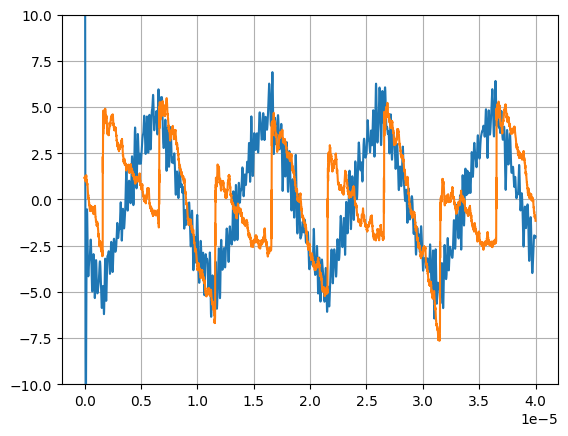

In [89]:
x= time .reshape((-1,1))
ylr2= LR.predict(x)
integVb2=integVb-ylr2


integVb2=integVb2-integVb2.mean()

k2= 1.4
integVb2=integVb2*k2
plt.plot(time[1:], ic2)
plt.ylim([-10,10])
plt.plot(time, integVb2)


plt.grid()

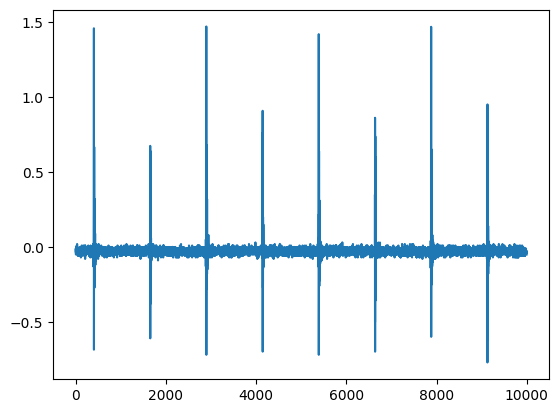

In [91]:
plt.plot(vb)

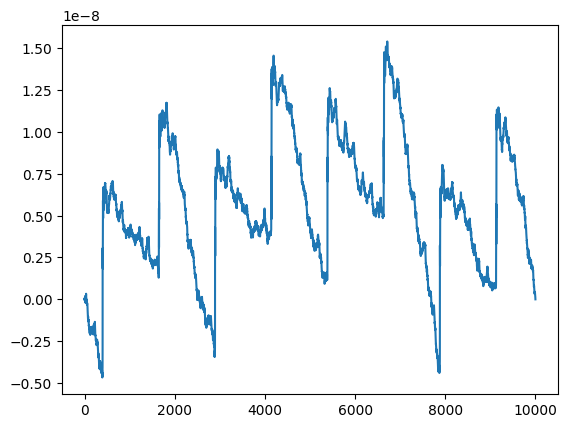

In [95]:
vb2= vb-vb.mean()
integVb= np.cumsum(vb2)*Ts
plt.plot(integVb)

In [96]:
import scipy
tpz=scipy.integrate.cumulative_trapezoid

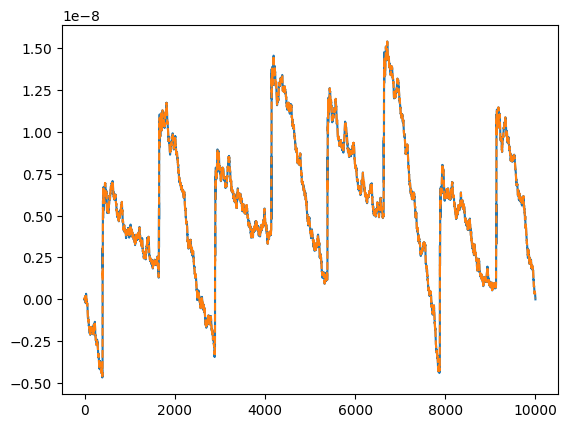

In [106]:
vb2= vb-vb.mean()
integVb2= tpz(y=vb2 , dx= Ts)
integVb= np.cumsum(vb2)*Ts
plt.plot(integVb)
plt.plot(integVb2, linestyle="--")

In [109]:
np.median(vb), vb.mean()

(np.float64(-0.03), np.float64(-0.026269304687499998))

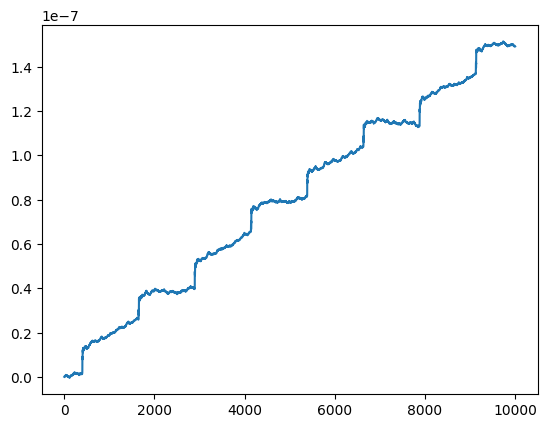

In [113]:
vb2= vb-np.median(vb)
#integVb2= tpz(y=vb2 , dx= Ts)
integVb= np.cumsum(vb2)*Ts
plt.plot(integVb)
#plt.plot(integVb2, linestyle="--")

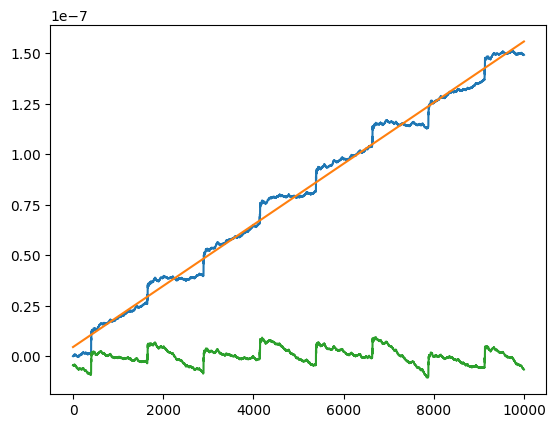

In [116]:
vb2= vb-np.median(vb)
integVb= np.cumsum(vb2)*Ts
plt.plot(integVb)

x= time .reshape((-1,1))
y= integVb
LR= LinearRegression().fit(x,y)
ylr= LR.predict(x)
plt.plot(ylr)
plt.plot(integVb-ylr)

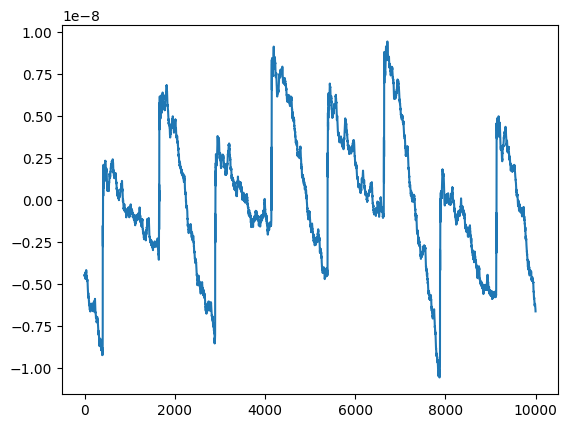

In [117]:
plt.plot(integVb-ylr)

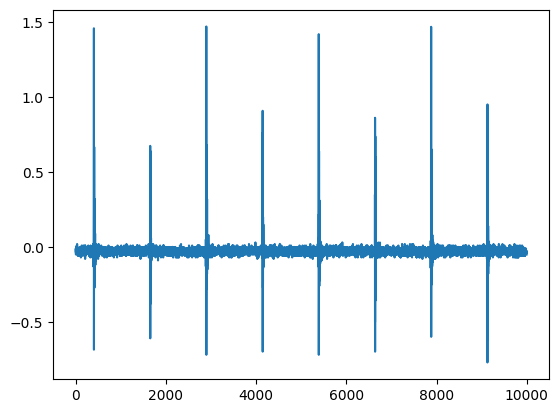

In [118]:
plt.plot(vb)

[ 402 2895 5388 7881]


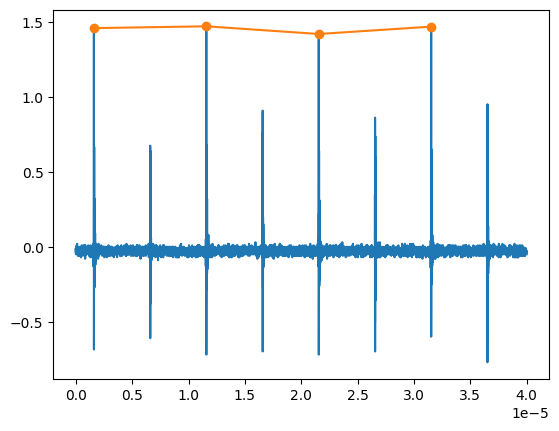

In [128]:
indx = np.where(vb>1)[0]
print(indx )
plt.plot(time, vb)
plt.plot(time[indx], vb[indx], marker="o")

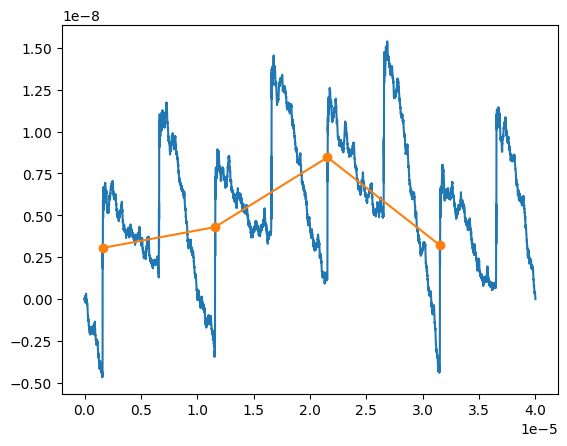

In [131]:
vb2= vb-vb.mean()
integVb= np.cumsum(vb2)*Ts
plt.plot(time, integVb)
plt.plot(time[indx], integVb[indx], marker="o")

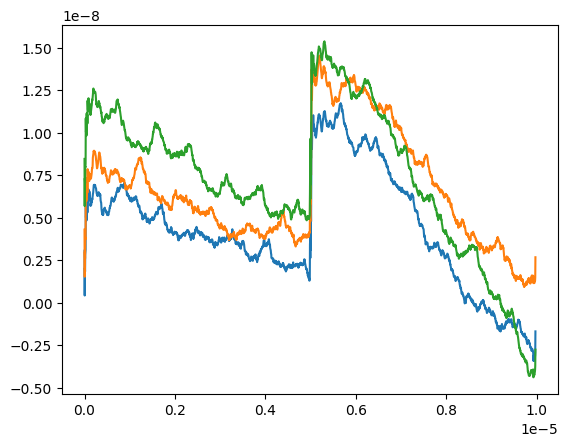

In [135]:
for k in range(1, len(indx)):
    i_1 = indx[k-1]
    i = indx[k]
    t= time[i_1:i]
    t=t-t[0]
    plt.plot(t, integVb[i_1:i])
    

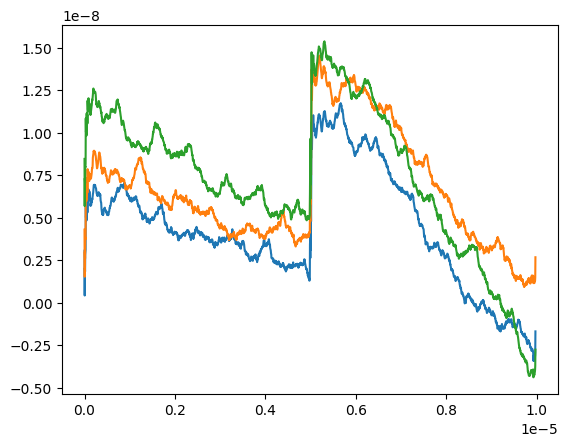

In [136]:
for k in range(1, len(indx)):
    i_1 = indx[k-1]
    i = indx[k]
    t= time[i_1:i]
    t=t-t[0]
    v=integVb[i_1:i]
    plt.plot(t, v)
    

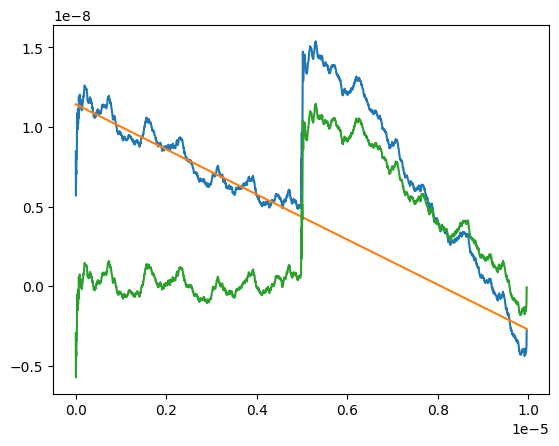

In [147]:
n=len(t)
t2= t[int(0.1*n):int(0.4*n)]
v2 = v[int(0.1*n):int(0.4*n)]
x= t2 .reshape((-1,1))


LR= LinearRegression().fit(x,v2)
x= t .reshape((-1,1))
ylr= LR.predict(x)
plt.plot(t, v)
plt.plot(x, ylr)
plt.plot(x, v-ylr)

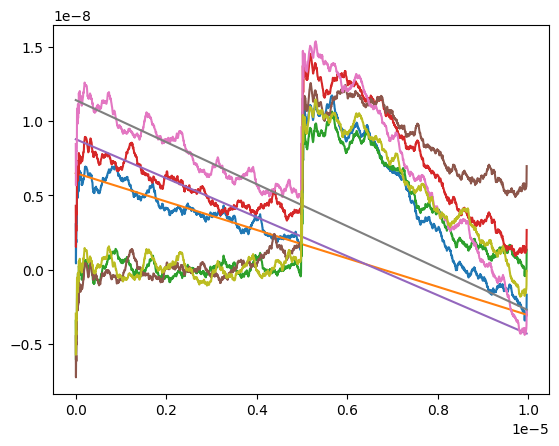

In [168]:
arrt=[]
arrI=[]
arric = []
for k in range(1, len(indx)):
    i_1 = indx[k-1]
    i = indx[k]
    t= time[i_1:i]
    t=t-t[0]
    v=integVb[i_1:i]
    arric.append(ic2[i_1:i])

    n=len(t)
    t2= t[int(0.1*n):int(0.4*n)]
    v2 = v[int(0.1*n):int(0.4*n)]
    x= t2 .reshape((-1,1))
    
    
    LR= LinearRegression().fit(x,v2)
    x= t .reshape((-1,1))
    ylr= LR.predict(x)
    plt.plot(t, v)
    plt.plot(x, ylr)
    plt.plot(x, v-ylr)
    arrt.append(x.flatten())
    arrI.append( v-ylr)

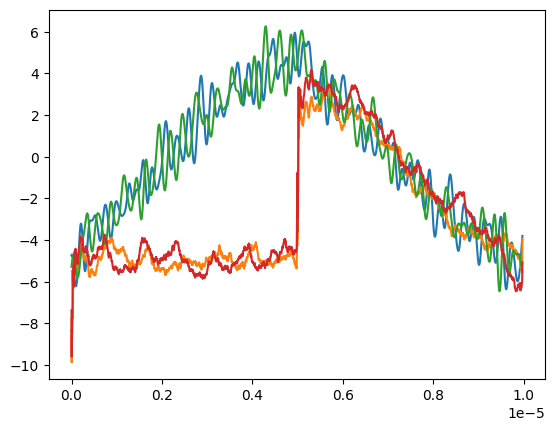

In [179]:

for k in range( len(arrt)):
    t= arrt[k]
    amp=8e8
    i = amp*arrI[k]-5
    if k==1: 
        continue
    ic_= arric [k]
    plt.plot(t, ic_)
    plt.plot(t, i)
plt.show()

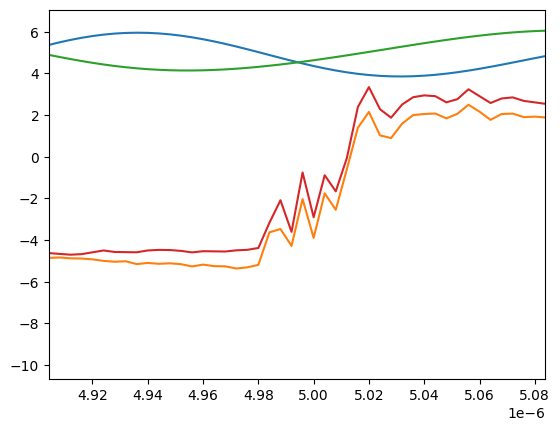

In [193]:

for k in range( len(arrt)):
    t= arrt[k]
    amp=8e8
    i = amp*arrI[k]-5
    if k==1: 
        continue
    ic_= arric [k]
    plt.plot(t, ic_)
    plt.plot(t, i)
    

dx = t.max()-t.min()
plt.xlim([0.492*dx, 0.51*dx])
plt.show()

In [187]:
dx

np.float64(9.968000000000003e-06)